In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("09-iris.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

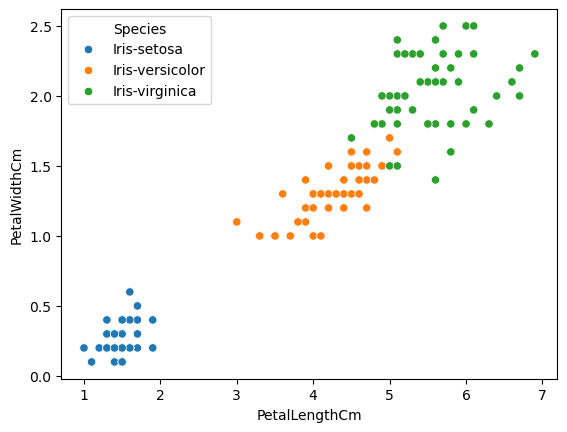

In [5]:
sns.scatterplot(x=df["PetalLengthCm"],y=df["PetalWidthCm"], hue=df['Species'])

In [6]:
df = df.drop('Id', axis=1)

In [7]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].values
Y = df['Species'].values

In [9]:
from sklearn.preprocessing import LabelEncoder

In [33]:
le = LabelEncoder()
Y = le.fit_transform(Y) # tahmin etmeye çalıştığımız bilgi string olduğu için bir bir sınıf için değeri belirler

In [11]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_test, X_train, Y_test, Y_train = train_test_split(X, Y, test_size=0.2, train_size=0.8, random_state=42, stratify=Y)

In [15]:
X_test = torch.tensor(X_test,  dtype=torch.float32)
X_train =torch.tensor(X_train, dtype=torch.float32)

Y_test =torch.tensor(Y_test, dtype=torch.long)
Y_train =torch.tensor(Y_train, dtype=torch.long)

In [16]:
print(X_test.shape, X_train.shape)
print(Y_test.shape, Y_train.shape)

torch.Size([120, 4]) torch.Size([30, 4])
torch.Size([120]) torch.Size([30])


In [17]:
from torch import nn

In [18]:
#class IrisClassifier(nn.Module):
 #   def __init__(self):
  #      super().__init__()
   #     self.layer_1 =  nn.Linear(in_features=4,out_features=16)
    #    self.layer_2 =  nn.Linear(in_features=16,out_features=16)
     #   self.layer_3 =  nn.Linear(in_features=16,out_features=3)
#
 #       self.relu = nn.ReLU()
#
 #   def forward(self, x) -> torch.tensor:
  #      return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [19]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 3), # 3 classes    
        )
        
    def forward(self, x) -> torch.tensor:
        return self.linear_layer_stack(x)

In [20]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)

In [21]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) *100
    return acc

In [22]:
model(X_test)[0].shape

torch.Size([3])

In [23]:
Y_logits = model(X_test) 

In [24]:
Y_pred_probs = torch.softmax(Y_logits, dim = 1) #modelin yapıtğı tahminleri olasılığa çevirir

In [25]:
Y_logits[:5]

tensor([[-0.1718,  0.1320, -0.6411],
        [-0.0823,  0.1365, -0.8012],
        [-0.0409,  0.2370, -0.9986],
        [-0.1660,  0.1607, -0.6866],
        [-0.0705,  0.1571, -0.8451]], grad_fn=<SliceBackward0>)

In [26]:
Y_pred_probs[:5]

tensor([[0.3355, 0.4546, 0.2099],
        [0.3661, 0.4556, 0.1784],
        [0.3698, 0.4883, 0.1419],
        [0.3355, 0.4651, 0.1993],
        [0.3681, 0.4622, 0.1697]], grad_fn=<SliceBackward0>)

In [27]:
torch.sum(Y_pred_probs[4])

tensor(1., grad_fn=<SumBackward0>)

In [28]:
Y_pred_probs[0]

tensor([0.3355, 0.4546, 0.2099], grad_fn=<SelectBackward0>)

In [29]:
torch.argmax(Y_pred_probs[0])

tensor(1)

In [30]:
torch.argmax(Y_pred_probs)

tensor(67)

In [31]:
len(Y_pred_probs)

120

In [34]:
torch.softmax(Y_logits, dim = 1).argmax(dim=1) #olasılıklar arasından en büyük olanı seçer ve o olasılığın belirtiği sınıfı verir.

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])